# Exploracion de similitud entre embeddings

Este notebook sirve para investigar si los embeddings son muy parecidos entre si.

Incluye:
- Seleccion automatica de columnas de embedding (CLIP o CNN PCA).
- Distribucion de similitud coseno entre pares aleatorios.
- Analisis de vecinos mas cercanos por creative.
- Deteccion de pares casi duplicados con umbral configurable.
- Visualizacion 2D (PCA) para inspeccion manual.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)

CSV_PATH = Path('../outputs/creative_visual_features_with_embeddings_pca.csv')
EMBEDDING_FAMILY = 'clip'  # 'clip' o 'cnn'
ID_COL = 'creative_id'
META_COLS = ['campaign_id', 'advertiser_name', 'app_name', 'vertical', 'format']
RANDOM_PAIRS = 30000
K_NEIGHBORS = 6
NEAR_DUP_THRESHOLD = 0.98
RANDOM_STATE = 42

print(f'CSV_PATH = {CSV_PATH.resolve()}')
print(f'EMBEDDING_FAMILY = {EMBEDDING_FAMILY}')

CSV_PATH = C:\Users\sylbo\Documents_local\hack_UPC_2026\fe_vision_v2\outputs\creative_visual_features_with_embeddings_pca.csv
EMBEDDING_FAMILY = clip


In [2]:
df = pd.read_csv(CSV_PATH)
print(f'Filas: {len(df):,} | Columnas: {df.shape[1]}')

prefix = f'{EMBEDDING_FAMILY}_pca_'
emb_cols = [c for c in df.columns if c.startswith(prefix)]

if not emb_cols:
    raise ValueError(f'No se encontraron columnas con prefijo: {prefix}')

print(f'Embedding cols detectadas: {len(emb_cols)}')
print('Primeras 5:', emb_cols[:5])

missing_cols = [c for c in [ID_COL, *META_COLS] if c not in df.columns]
if missing_cols:
    print(f'Aviso: faltan columnas de metadatos: {missing_cols}')

Filas: 1,080 | Columnas: 233
Embedding cols detectadas: 64
Primeras 5: ['clip_pca_0', 'clip_pca_1', 'clip_pca_2', 'clip_pca_3', 'clip_pca_4']


In [3]:
X = df[emb_cols].to_numpy(dtype=np.float32)

# Normalizamos para que el producto punto sea similitud coseno.
norms = np.linalg.norm(X, axis=1, keepdims=True)
norms = np.clip(norms, 1e-12, None)
Xn = X / norms

print('Shape embeddings:', Xn.shape)
print('Norma media (antes):', float(np.mean(np.linalg.norm(X, axis=1))))
print('Norma media (despues):', float(np.mean(np.linalg.norm(Xn, axis=1))))

Shape embeddings: (1080, 64)
Norma media (antes): 0.6096553802490234
Norma media (despues): 1.0


Resumen similitud coseno (pares aleatorios):
count    29970.000000
mean         0.000182
std          0.195754
min         -0.421457
1%          -0.294926
5%          -0.233142
50%         -0.040791
95%          0.381827
99%          0.705849
max          0.999112
dtype: float64


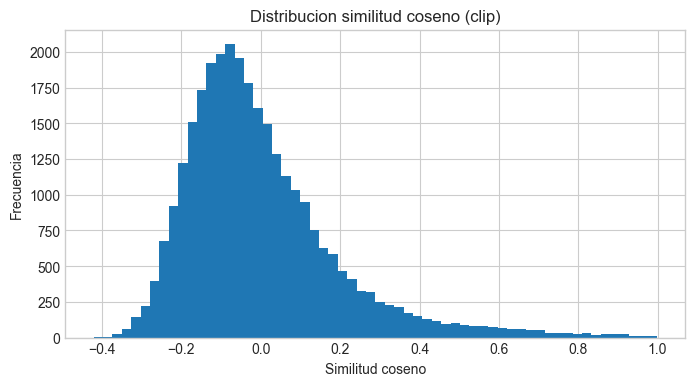

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
n = Xn.shape[0]
n_pairs = min(RANDOM_PAIRS, n * (n - 1) // 2)

i = rng.integers(0, n, size=n_pairs)
j = rng.integers(0, n, size=n_pairs)
mask = i != j
i, j = i[mask], j[mask]

sample_sims = np.sum(Xn[i] * Xn[j], axis=1)

print('Resumen similitud coseno (pares aleatorios):')
print(pd.Series(sample_sims).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

plt.figure(figsize=(8, 4))
plt.hist(sample_sims, bins=60)
plt.title(f'Distribucion similitud coseno ({EMBEDDING_FAMILY})')
plt.xlabel('Similitud coseno')
plt.ylabel('Frecuencia')
plt.show()

Similitud al vecino mas cercano (excluyendo self):
count    1080.000000
mean        0.901746
std         0.092816
min         0.492463
50%         0.926505
90%         0.996891
95%         1.000000
99%         1.000000
max         1.000000
dtype: float64


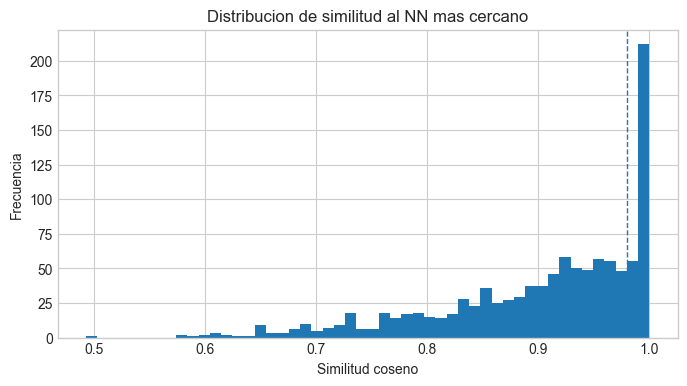

In [5]:
nn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='cosine')
nn.fit(Xn)
distances, indices = nn.kneighbors(Xn)

# metric='cosine' devuelve distancia coseno, asi que similitud = 1 - distancia.
sim_neighbors = 1.0 - distances
best_nonself_sim = sim_neighbors[:, 1]

print('Similitud al vecino mas cercano (excluyendo self):')
print(pd.Series(best_nonself_sim).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure(figsize=(8, 4))
plt.hist(best_nonself_sim, bins=50)
plt.axvline(NEAR_DUP_THRESHOLD, linestyle='--', linewidth=1)
plt.title('Distribucion de similitud al NN mas cercano')
plt.xlabel('Similitud coseno')
plt.ylabel('Frecuencia')
plt.show()

In [6]:
# Pares casi duplicados en base a umbral sobre vecino mas cercano.
candidate_rows = np.where(best_nonself_sim >= NEAR_DUP_THRESHOLD)[0]
pair_rows = []
for r in candidate_rows:
    nn_idx = indices[r, 1]
    sim = best_nonself_sim[r]
    a, b = sorted((int(r), int(nn_idx)))
    pair_rows.append((a, b, float(sim)))

pairs_df = pd.DataFrame(pair_rows, columns=['row_a', 'row_b', 'cosine_sim']).drop_duplicates()
pairs_df = pairs_df.sort_values('cosine_sim', ascending=False).reset_index(drop=True)

print(f'Pares con similitud >= {NEAR_DUP_THRESHOLD}: {len(pairs_df):,}')
pairs_df.head(20)

Pares con similitud >= 0.98: 195


,row_a,row_b,cosine_sim
0,17,17,1.0
1,70,70,1.0
2,50,377,1.0
3,219,252,1.0
4,250,250,1.0
5,129,129,1.0
6,113,973,1.0
7,254,756,1.0
8,183,183,1.0
9,173,173,1.0


In [7]:
def enrich_pairs(pairs, base_df, id_col=ID_COL, meta_cols=META_COLS):
    keep_meta = [c for c in meta_cols if c in base_df.columns]
    cols = [id_col, *keep_meta] if id_col in base_df.columns else keep_meta

    left = base_df.iloc[pairs['row_a']][cols].reset_index(drop=True).add_prefix('a_')
    right = base_df.iloc[pairs['row_b']][cols].reset_index(drop=True).add_prefix('b_')

    out = pd.concat([pairs[['cosine_sim']].reset_index(drop=True), left, right], axis=1)
    return out

top_pairs = enrich_pairs(pairs_df.head(50), df)
top_pairs

,cosine_sim,a_creative_id,a_campaign_id,a_advertiser_name,a_app_name,a_vertical,a_format,b_creative_id,b_campaign_id,b_advertiser_name,b_app_name,b_vertical,b_format
0,1.0,500017,20002,EarnPath,EarnPath Invest,fintech,banner,500017,20002,EarnPath,EarnPath Invest,fintech,banner
1,1.0,500070,20011,FluxStream,FluxStream Play,entertainment,rewarded_video,500070,20011,FluxStream,FluxStream Play,entertainment,rewarded_video
2,1.0,500050,20008,CoinBridge,CoinBridge Invest,fintech,banner,500377,20062,ClearLedger,ClearLedger Cash,fintech,banner
3,1.0,500219,20036,PixelForge,PixelForge Legends,gaming,playable,500252,20042,NeonArena,NeonArena Arena,gaming,playable
4,1.0,500250,20041,MoonScreen,MoonScreen Stream,entertainment,interstitial,500250,20041,MoonScreen,MoonScreen Stream,entertainment,interstitial
5,1.0,500129,20021,RouteBloom,RouteBloom Getaway,travel,rewarded_video,500129,20021,RouteBloom,RouteBloom Getaway,travel,rewarded_video
6,1.0,500113,20018,StormByte,StormByte Saga,gaming,playable,500973,20162,StormByte,StormByte Arena,gaming,playable
7,1.0,500254,20042,NeonArena,NeonArena Arena,gaming,rewarded_video,500756,20126,StormByte,StormByte Arena,gaming,rewarded_video
8,1.0,500183,20030,IronQuest,IronQuest Saga,gaming,interstitial,500183,20030,IronQuest,IronQuest Saga,gaming,interstitial
9,1.0,500173,20028,QuickFork,QuickFork Kitchen,food_delivery,banner,500173,20028,QuickFork,QuickFork Kitchen,food_delivery,banner


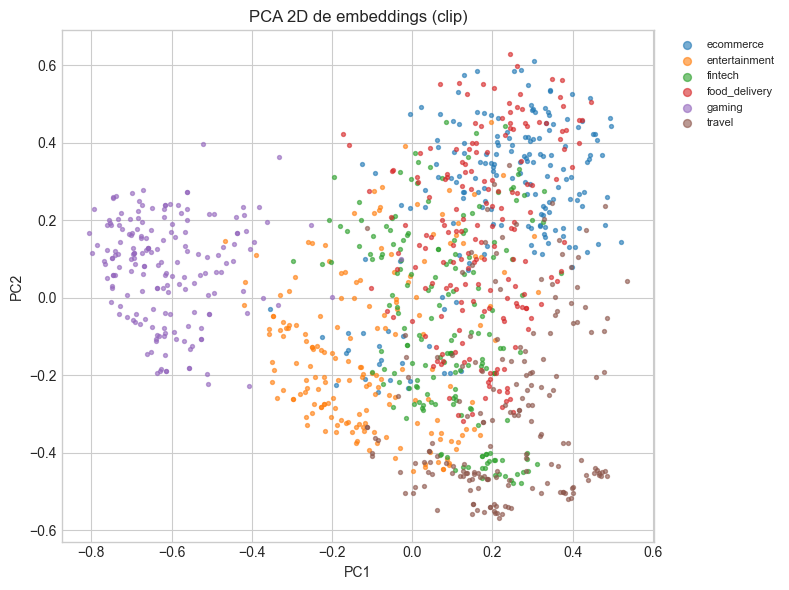

In [8]:
# Mapa 2D para inspeccion visual de clusters.
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca2.fit_transform(Xn)

plot_df = pd.DataFrame({'x': Z[:, 0], 'y': Z[:, 1]})
if 'vertical' in df.columns:
    plot_df['vertical'] = df['vertical'].astype(str)

sample_n = min(5000, len(plot_df))
plot_sample = plot_df.sample(sample_n, random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
if 'vertical' in plot_sample.columns:
    for v, g in plot_sample.groupby('vertical'):
        plt.scatter(g['x'], g['y'], s=8, alpha=0.6, label=v)
    plt.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
else:
    plt.scatter(plot_sample['x'], plot_sample['y'], s=8, alpha=0.6)

plt.title(f'PCA 2D de embeddings ({EMBEDDING_FAMILY})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

In [9]:
# Export opcional de resultados para compartir o auditar.
out_dir = Path('../outputs/embedding_similarity_analysis')
out_dir.mkdir(parents=True, exist_ok=True)

pairs_df.to_csv(out_dir / f'{EMBEDDING_FAMILY}_near_duplicates.csv', index=False)
top_pairs.to_csv(out_dir / f'{EMBEDDING_FAMILY}_top_similar_pairs_with_meta.csv', index=False)

summary = {
    'embedding_family': EMBEDDING_FAMILY,
    'n_rows': int(len(df)),
    'n_embedding_dims': int(len(emb_cols)),
    'random_pairs_evaluated': int(len(sample_sims)),
    'random_sim_mean': float(np.mean(sample_sims)),
    'random_sim_p95': float(np.quantile(sample_sims, 0.95)),
    'nn1_sim_mean': float(np.mean(best_nonself_sim)),
    'nn1_sim_p95': float(np.quantile(best_nonself_sim, 0.95)),
    'near_dup_threshold': float(NEAR_DUP_THRESHOLD),
    'near_dup_pairs': int(len(pairs_df)),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(out_dir / f'{EMBEDDING_FAMILY}_similarity_summary.csv', index=False)
summary_df

,embedding_family,n_rows,n_embedding_dims,random_pairs_evaluated,random_sim_mean,random_sim_p95,nn1_sim_mean,nn1_sim_p95,near_dup_threshold,near_dup_pairs
0,clip,1080,64,29970,0.000182,0.381827,0.901746,1.0,0.98,195
